# Dataset

For the training wdata we reach into the [PushshiftIO archive](https://pushshift.io/signup) and create random sample. We are using only the title, the text itself and the label derived  from the voting in the subreddit. Here is the [link](https://www.reddit.com/r/AITAH/) for the subreddit. Relevant thing in there is the rules that establish the label. It is based on democratic voting of other users.

# package installations

In [ ]:
pip install numpy pandas matplotlib seaborn torch scikit-learn transformers datasets

# Libraries used

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset
from torch import nn

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Initial setup and changable settings for optimalization etc

This part of the project contains everything needed for the notebook to work. Chosen model that is used for encoding and tokenization of the text, configuration for import file, hyperparameters settings.

In [2]:
#model selection - potential candidates
#MODEL_NAME = "albert-base-v2"            #smaller model
MODEL_NAME = "roberta-base"               # Best performance

# File paths
DATA_FILE = 'processed_sample_250000-1.csv'  # ← YOUR CSV FILE NAME HERE
OUTPUT_DIR = f'./final_model_{MODEL_NAME.replace("/", "_")}'

#small edit for readability of the code
CSV_COLUMNS = {
    'text': 'selftext',           # Column with post content
    'label': 'link_flair_text'    # Column with verdict/label
}

#label map
LABEL_MAP = {
    'Not the A-hole': 0,  # NTA
    'Asshole': 1          # YTA
}

ID2LABEL = {0: "NTA", 1: "YTA"}
LABEL2ID = {"NTA": 0, "YTA": 1}

#change hyperparameters here universally
TRAIN_CONFIG = {
    'test_size': 0.15,           # 15% for test
    'val_size': 0.10,            # 10% for validation
    'max_length': 512,           # BERT max sequence length
    'batch_size_train': 32,      # Training batch size
    'batch_size_eval': 64,       # Evaluation batch size
    'learning_rate': 1e-5,       # Learning rate
    'num_epochs': 4,             # Number of training epochs
    'warmup_steps': 500,         # Warmup steps
    'weight_decay': 0.05,        # Weight decay
    'random_state': 42
}

# Data preprocessing

## data import and basic cleaning


In [3]:
#load csv file
print(f"\nLoading data from {DATA_FILE}...")
df = pd.read_csv(
    DATA_FILE,
    engine="python",
    on_bad_lines="skip",
    sep=";",
    quotechar='"'
)
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")

#rename columns for consistency
text_col = CSV_COLUMNS['text']
label_col = CSV_COLUMNS['label']
df = df.rename(columns={
    text_col: 'full_text',
    label_col: 'label_text'
})


# Combine title + selftext (if title column exists)
if 'title' in df.columns:
    df['full_text'] = df['title'].fillna('') + ' ' + df['full_text'].fillna('')
    print("  Combined 'title' + 'selftext' into 'full_text'")
else:
    print("  No 'title' column found, using 'full_text' as-is")

#remove missing values
df = df[df['full_text'].notna()]
df = df[df['full_text'].str.strip() != '']
df = df[df['label_text'].notna()]

# Basic text cleaning
def clean_text(text):
    text = str(text)
    #remove excessive whitespaces
    text = ' '.join(text.split())
    if len(text) > 10000:
      #truncating long texts
        text = text[:10000]
    return text

df['full_text'] = df['full_text'].apply(clean_text)



Loading data from processed_sample_250000-1.csv...
  Shape: (249995, 3)
  Columns: ['selftext', 'link_flair_text', 'target']
  No 'title' column found, using 'full_text' as-is


## Labels transformation

Since we are going to  use only the binary and decisive labels. it is easier for the classification as well as the other labels are only small fraction of the labels.

In [4]:
print(f"\n Filtering to keep only 'Not the A-hole' and 'Asshole'...")

#size before filtering
before = len(df)
print(f"Before filtering: {before:,} posts")

#keeping only these 2 labels (exact match)
valid_labels = ['Not the A-hole', 'Asshole']
df = df[df['label_text'].isin(valid_labels)]

#size afterfter filtering
after = len(df)
dropped = before - after
print(f"After filtering: {after:,} posts")
print(f"Dropped: {dropped:,} posts")

# Show final distribution
print(f"\n Final label distribution:")
for label, count in df['label_text'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  '{label}': {count:,} ({pct:.1f}%)")



#variable encoding
# Using LABEL_MAP from config (phase 0)
df['label'] = df['label_text'].map(LABEL_MAP)

# Check for unmapped labels (should be 0 after filtering above)
unmapped = df[df['label'].isna()]
if len(unmapped) > 0:
    print(f"  WARNING: {len(unmapped)} samples have unmapped labels")
    print(f"  Unique unmapped values: {unmapped['label_text'].unique()}")
    df = df[df['label'].notna()]

df['label'] = df['label'].astype(int)

# Display final label distribution
print(f"\n Encoded label distribution:")
label_counts = df['label'].value_counts().sort_index()
for label_id, count in label_counts.items():
    label_name = ID2LABEL[label_id]
    original_text = [k for k, v in LABEL_MAP.items() if v == label_id][0]
    percentage = count / len(df) * 100
    print(f"  {label_name} ('{original_text}'): {count:,} ({percentage:.1f}%)")

# Check class imbalance
if len(label_counts) >= 2:
    class_ratio = label_counts.max() / label_counts.min()
    print(f"\nClass imbalance ratio: {class_ratio:.2f}:1")
    if class_ratio > 2:
        print("Significant class imbalance detected. Will use weighted loss.")
    elif class_ratio > 1.5:
        print("Moderate class imbalance. Weighted loss recommended.")
    else:
        print("Classes are relatively balanced.")

# Display text statistics
print(f"\n Text statistics:")
text_lengths = df['full_text'].str.len()
print(f"  Mean length: {text_lengths.mean():.1f} characters")
print(f"  Median length: {text_lengths.median():.1f} characters")
print(f"  Min length: {text_lengths.min()} characters")
print(f"  Max length: {text_lengths.max():,} characters")
print(f"  Std dev: {text_lengths.std():.1f} characters")

# Show example posts
print(f"\n Example posts:")
for label_name in ['Not the A-hole', 'Asshole']:
    if label_name in df['label_text'].values:
        sample = df[df['label_text'] == label_name].iloc[0]
        print(f"\n  '{label_name}' example:")
        print(f"    {sample['full_text'][:200]}...")

print(f"\n Data preparation complete!")
print(f"   Final dataset: {len(df):,} posts ready for training")



 Filtering to keep only 'Not the A-hole' and 'Asshole'...
Before filtering: 249,905 posts
After filtering: 246,805 posts
Dropped: 3,100 posts

 Final label distribution:
  'Not the A-hole': 196,551 (79.6%)
  'Asshole': 50,254 (20.4%)

 Encoded label distribution:
  NTA ('Not the A-hole'): 196,551 (79.6%)
  YTA ('Asshole'): 50,254 (20.4%)

Class imbalance ratio: 3.91:1
Significant class imbalance detected. Will use weighted loss.

 Text statistics:
  Mean length: 1874.4 characters
  Median length: 1799.0 characters
  Min length: 1 characters
  Max length: 10,000 characters
  Std dev: 855.9 characters

 Example posts:

  'Not the A-hole' example:
    Background: Earlier, in the highscool 1st grade, i make a friend group which i enjoy to be together for a long time. we were playing LoL, cs go and stuff like that. it was pretty much thing for me tho...

  'Asshole' example:
    I'm visiting with my parents for a month. It's nice to stay with them for a whole month, and they often share fo

# Split before training

Stratified splitting to keep the split sets representative is important since later on we use weights for the minority class in training.

In [5]:
# Select only needed columns
df_clean = df[['full_text', 'label']].copy()

# First split: separate test set
train_val_df, test_df = train_test_split(
    df_clean,
    test_size=TRAIN_CONFIG['test_size'],
    random_state=TRAIN_CONFIG['random_state'],
    stratify=df_clean['label']
)

# Second split: separate validation set
val_ratio = TRAIN_CONFIG['val_size'] / (1 - TRAIN_CONFIG['test_size'])
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_ratio,
    random_state=TRAIN_CONFIG['random_state'],
    stratify=train_val_df['label']
)

print(f"\nDataset split:")
print(f"  Train: {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")

# Verify class distribution in splits
print("\nClass distribution in each split:")
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split_df['label'].value_counts().sort_index()
    print(f"  {split_name}:")
    for label_id, count in counts.items():
        print(f"    {ID2LABEL[label_id]}: {count} ({count/len(split_df)*100:.1f}%)")



PHASE 2: TRAIN/VAL/TEST SPLIT

Dataset split:
  Train: 185,103 samples (75.0%)
  Val:   24,681 samples (10.0%)
  Test:  37,021 samples (15.0%)

Class distribution in each split:
  Train:
    NTA: 147413 (79.6%)
    YTA: 37690 (20.4%)
  Val:
    NTA: 19655 (79.6%)
    YTA: 5026 (20.4%)
  Test:
    NTA: 29483 (79.6%)
    YTA: 7538 (20.4%)


# Tokenization

For computation reasons we only limit the texts on length of 512 tokens. The longer posts are just cut after 512 tokens. This is keeps almost 64% of the posts untouched. Before traning the posts smaller than 512 tokens are padded so we have uniform input into the model of 512 length vectors.


Loading tokenizer: roberta-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

  Vocab size: 50,265
  Model max length: 512

Analyzing text lengths...

Token length statistics (sample of 1000):
  Mean: 441.8
  Median: 423.5
  Max: 1315
  95th percentile: 746.1
  99th percentile: 884.3

Texts that will be truncated: 36.2%

Saved: token_length_distribution.png


Map:   0%|          | 0/185103 [00:00<?, ? examples/s]

Map:   0%|          | 0/24681 [00:00<?, ? examples/s]

Map:   0%|          | 0/37021 [00:00<?, ? examples/s]

  Train dataset: 185103 samples
  Val dataset: 24681 samples
  Test dataset: 37021 samples


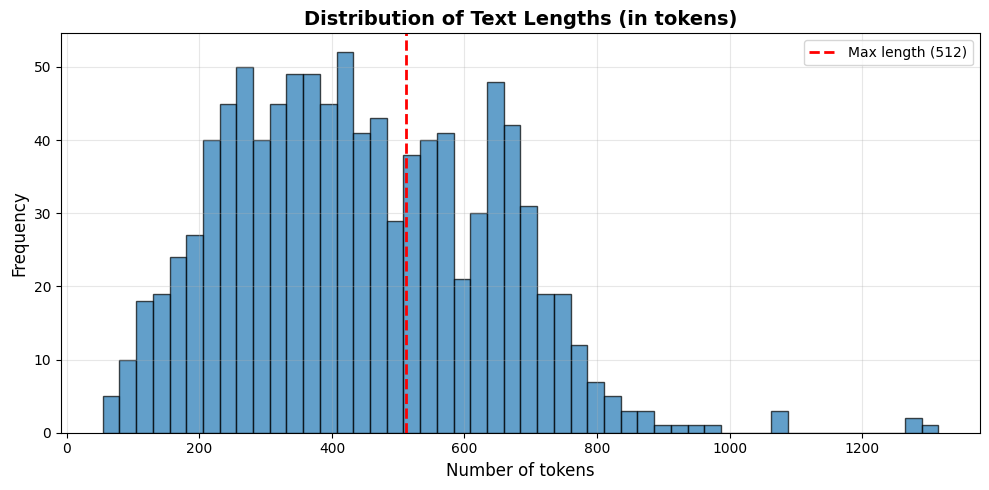

In [6]:
#load tokenizer
print(f"\nLoading tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"  Vocab size: {tokenizer.vocab_size:,}")
print(f"  Model max length: {tokenizer.model_max_length}")

# Analyze text lengths
print("\nAnalyzing text lengths...")
train_lengths = []
for text in train_df['full_text'].values[:1000]:  # Sample for speed
    tokens = tokenizer.encode(text, truncation=False, add_special_tokens=True)
    train_lengths.append(len(tokens))

train_lengths = np.array(train_lengths)

print(f"\nToken length statistics (sample of 1000):")
print(f"  Mean: {train_lengths.mean():.1f}")
print(f"  Median: {np.median(train_lengths):.1f}")
print(f"  Max: {train_lengths.max()}")
print(f"  95th percentile: {np.percentile(train_lengths, 95):.1f}")
print(f"  99th percentile: {np.percentile(train_lengths, 99):.1f}")

truncated_pct = (train_lengths > TRAIN_CONFIG['max_length']).sum() / len(train_lengths) * 100
print(f"\nTexts that will be truncated: {truncated_pct:.1f}%")

#length distribution plot
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(TRAIN_CONFIG['max_length'], color='red', linestyle='--',
            label=f'Max length ({TRAIN_CONFIG["max_length"]})', linewidth=2)
plt.xlabel('Number of tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Text Lengths (in tokens)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('token_length_distribution.png', dpi=300, bbox_inches='tight')
print("\nSaved: token_length_distribution.png")

#create HF datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

#tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['full_text'],
        padding=False,  # Let DataCollatorWithPadding handle padding per-batch (more efficient)
        truncation=True,
        max_length=TRAIN_CONFIG['max_length'],
        return_tensors=None
    )

#tokenize datasets
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=['full_text']
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=['full_text']
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=['full_text']
)

#rename and format for convenience
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


print(f"  Train dataset: {len(train_dataset)} samples")
print(f"  Val dataset: {len(val_dataset)} samples")
print(f"  Test dataset: {len(test_dataset)} samples")

# Model setup

The weights are chosen arbitrarily after couple of times of running the classifier. In following code we also define the model. Classifier is a neural network which takes the CLS token (classification token) that summarizes the text and runs it through the network. this network is trained on hyperparameters set earlier.


In [7]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Load model
print(f"\nLoading model: {MODEL_NAME}...")
num_labels = len(LABEL_MAP)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    problem_type="single_label_classification"
)

print(f"Model loaded successfully!")
print(f"  Total parameters: {model.num_parameters():,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


#manually added weights to fight the imbalance
class_weights = torch.tensor([1.0, 8.0], dtype=torch.float)


print(f"\nClass weights (for weighted loss):")
for i, weight in enumerate(class_weights):
    print(f"  {ID2LABEL[i]}: {weight:.3f}")

print(f"Weight ratio (YTA:NTA): {class_weights[1]/class_weights[0]:.2f}:1")


class WeightedTrainer(Trainer):
    """
    Custom Trainer that applies class weights to handle imbalanced data.

    This modifies the loss calculation to make YTA errors 8× more impactful
    than NTA errors, forcing the model to learn the minority class better.
    """

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Override the default loss computation to apply class weights.

        Args:
            model: The RoBERTa model
            inputs: Batch of tokenized inputs with labels
            return_outputs: Whether to return model outputs (for evaluation)

        Returns:
            loss: Weighted cross-entropy loss
            outputs (optional): Model outputs if return_outputs=True
        """
        #Extract labels from inputs
        labels = inputs.pop("labels")

        #Forward pass through model
        outputs = model(**inputs)
        logits = outputs.logits

        #Apply weighted cross-entropy loss
        #This applies our [1.0, 6.0] weights to make YTA errors 6× more costly
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

print("This trainer will apply 8× weight to YTA errors during training.")


Using device: cpu

Loading model: roberta-base...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!
  Total parameters: 124,647,170
  Trainable parameters: 124,647,170

Class weights (for weighted loss):
  NTA: 1.000
  YTA: 8.000
Weight ratio (YTA:NTA): 8.00:1
This trainer will apply 8× weight to YTA errors during training.


# Evaluation function and hyperparameters setup

Here we create function that calculates all the metrics used in training of the NN.

In [11]:
# one function to calculate metrics
def compute_metrics(eval_pred):
    """Compute evaluation metrics"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    precision_macro = precision_score(labels, predictions, average='macro', zero_division=0)
    recall_macro = recall_score(labels, predictions, average='macro', zero_division=0)

    #Per-class metrics
    f1_per_class = f1_score(labels, predictions, average=None, zero_division=0)
    precision_per_class = precision_score(labels, predictions, average=None, zero_division=0)
    recall_per_class = recall_score(labels, predictions, average=None, zero_division=0)

    metrics = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
    }

    # Add per-class metrics
    for i in range(len(f1_per_class)):
        metrics[f'f1_{ID2LABEL[i]}'] = f1_per_class[i]
        metrics[f'precision_{ID2LABEL[i]}'] = precision_per_class[i]
        metrics[f'recall_{ID2LABEL[i]}'] = recall_per_class[i]

    return metrics




# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=TRAIN_CONFIG['learning_rate'],
    per_device_train_batch_size=TRAIN_CONFIG['batch_size_train'],
    per_device_eval_batch_size=TRAIN_CONFIG['batch_size_eval'],
    num_train_epochs=TRAIN_CONFIG['num_epochs'],
    weight_decay=TRAIN_CONFIG['weight_decay'],
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=50,
    logging_first_step=True,
    warmup_steps=TRAIN_CONFIG['warmup_steps'],
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    seed=TRAIN_CONFIG['random_state'],
    report_to="none",
    optim="adamw_torch"
)

print("\nTraining configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Train batch size: {training_args.per_device_train_batch_size}")
print(f"  Eval batch size: {training_args.per_device_eval_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Warmup steps: {training_args.warmup_steps}")
print(f"  Weight decay: {training_args.weight_decay}")
print(f"  FP16 training: {training_args.fp16}")

#data collator - used for padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Initialize trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("\nTrainer initialized!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Training configuration:
  Epochs: 4
  Train batch size: 32
  Eval batch size: 64
  Learning rate: 1e-05
  Warmup steps: 500
  Weight decay: 0.05
  FP16 training: False

Trainer initialized!


# Training

In [12]:
#estimating training time
steps_per_epoch = len(train_dataset) // (TRAIN_CONFIG['batch_size_train'] * torch.cuda.device_count() if torch.cuda.is_available() else 1)
total_steps = steps_per_epoch * TRAIN_CONFIG['num_epochs']
print(f"\nEstimated steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {total_steps}")

#train
train_result = trainer.train()

#training summary
print("TRAINING COMPLETE")
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds ({train_result.metrics['train_runtime']/60:.1f} minutes)")
print(f"Samples per second: {train_result.metrics['train_samples_per_second']:.2f}")


Estimated steps per epoch: 185103
Total training steps: 740412


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,F1 Nta,Precision Nta,Recall Nta,F1 Yta,Precision Yta,Recall Yta
1,0.533953,0.540896,0.600462,0.571292,0.637575,0.622127,0.687321,0.683120,0.927163,0.540778,0.459464,0.317092,0.833864
2,0.478485,0.633426,0.754102,0.672746,0.769460,0.660486,0.706928,0.835915,0.891934,0.786517,0.509576,0.429038,0.627338
3,0.497194,0.567693,0.691706,0.637927,0.720637,0.643482,0.714177,0.777469,0.914294,0.676266,0.498385,0.372671,0.752089
4,0.420384,0.645214,0.718123,0.655017,0.742473,0.650673,0.716251,0.802565,0.907457,0.719410,0.507469,0.393889,0.713092


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TRAINING COMPLETE
Training loss: 0.4847
Training time: 3754.71 seconds (62.6 minutes)
Samples per second: 197.21


# Evaluation



Validation Set Evaluation:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Validation Metrics:
  epoch: 4.0000
  eval_accuracy: 0.7541
  eval_f1_NTA: 0.8359
  eval_f1_YTA: 0.5094
  eval_f1_macro: 0.6726
  eval_f1_weighted: 0.7694
  eval_loss: 0.6345
  eval_precision_NTA: 0.8918
  eval_precision_YTA: 0.4289
  eval_precision_macro: 0.6604
  eval_recall_NTA: 0.7866
  eval_recall_YTA: 0.6269
  eval_recall_macro: 0.7068
  eval_samples_per_second: 458.0230
  eval_steps_per_second: 7.1570

Test Set Evaluation:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Classification Report:
              precision    recall  f1-score   support

         NTA     0.8922    0.7900    0.8380     29483
         YTA     0.4327    0.6266    0.5119      7538

    accuracy                         0.7567     37021
   macro avg     0.6625    0.7083    0.6750     37021
weighted avg     0.7986    0.7567    0.7716     37021


Overall Test Set Metrics:
  Accuracy:     0.7567 (75.67%)
  F1 (macro):   0.6750
  F1 (weighted): 0.7716

💾 Saved: confusion_matrix.png

Confusion Matrix Breakdown:
  True NTA → Predicted NTA: 23292 ( 79.0%)
  True NTA → Predicted YTA: 6191 ( 21.0%)
  True YTA → Predicted NTA: 2815 ( 37.3%)
  True YTA → Predicted YTA: 4723 ( 62.7%)

Prediction Confidence:
  Correct predictions:
    Mean: 0.824
    Std:  0.129
  Incorrect predictions:
    Mean: 0.723
    Std:  0.134


/tmp/ipykernel_389/218769040.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([correct_confidences, incorrect_confidences],


Saved: prediction_confidence.png

Misclassified Examples: 9006 (24.3%)

Showing first 3 misclassifications:

  Example 1:
    True label:  YTA
    Predicted:   NTA
    Confidence:  55.45%
    Text (first 150 chars): A while back my group of friends decided to go to a party at a hotel. We decided that before the party we would all meet at Gerald’s house and take a ...
    Score breakdown: NTA=0.554 YTA=0.446 

  Example 2:
    True label:  NTA
    Predicted:   YTA
    Confidence:  91.98%
    Text (first 150 chars): I am an older man, and I work a more dangerous than average job, so I've decided to begin drafting my will, just in case. I don't have a lot of assets...
    Score breakdown: NTA=0.080 YTA=0.920 

  Example 3:
    True label:  NTA
    Predicted:   YTA
    Confidence:  50.49%
    Text (first 150 chars): I work a Union job so vacation weeks have to be picked the year before (Thanksgiving 2022 we take all our weeks, for example) My spouse hadn’t worked ...
    Score breakdown: N

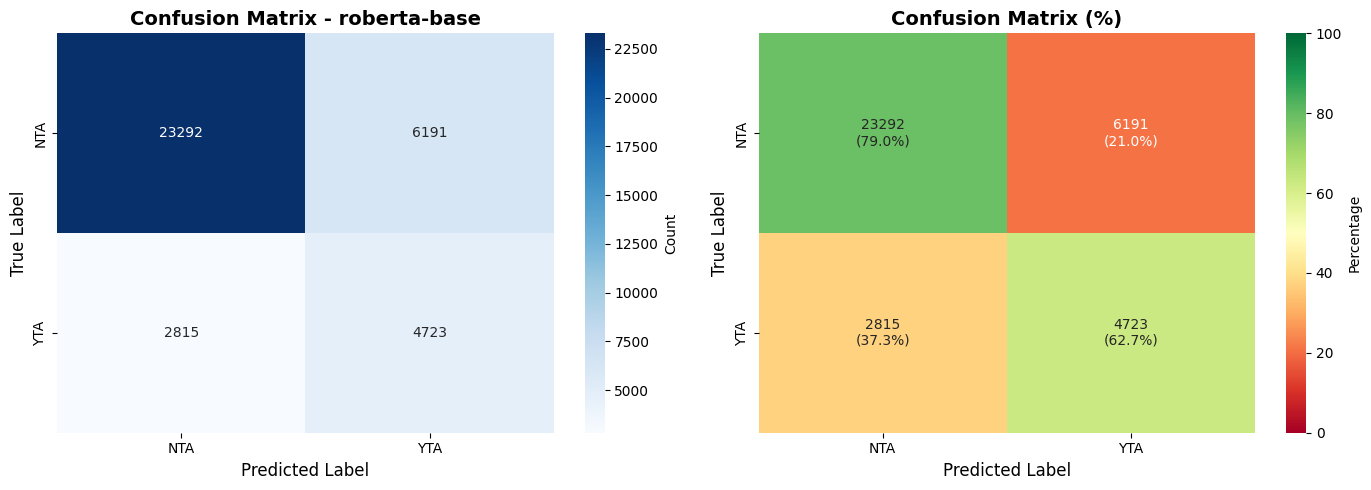

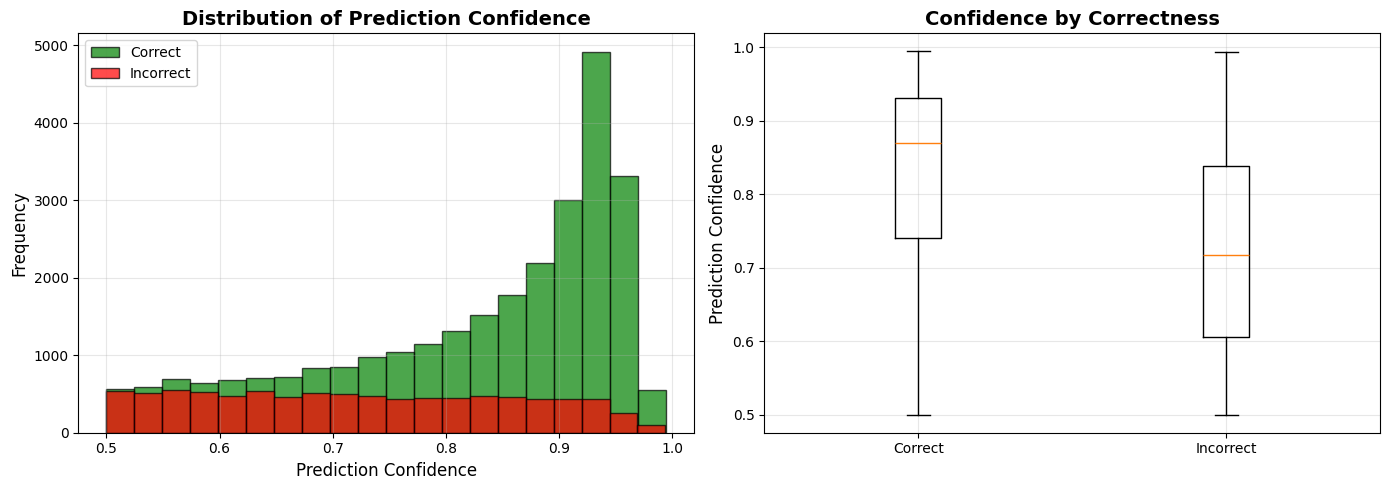

In [17]:
#evaluate on validation set
print("\nValidation Set Evaluation:")
val_results = trainer.evaluate()

print("\nValidation Metrics:")
for key, value in sorted(val_results.items()):
    if not key.startswith('eval_runtime'):
        print(f"  {key}: {value:.4f}")

#evaluate on test set
print("\nTest Set Evaluation:")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

#classification report
print("\nClassification Report:")
print(classification_report(
    labels,
    preds,
    target_names=list(ID2LABEL.values()),
    digits=4
))

#overall metrics
accuracy = accuracy_score(labels, preds)
f1_macro = f1_score(labels, preds, average='macro')
f1_weighted = f1_score(labels, preds, average='weighted')

print(f"\nOverall Test Set Metrics:")
print(f"  Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  F1 (macro):   {f1_macro:.4f}")
print(f"  F1 (weighted): {f1_weighted:.4f}")

#confusion Matrix
cm = confusion_matrix(labels, preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(ID2LABEL.values()),
            yticklabels=list(ID2LABEL.values()),
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix - {MODEL_NAME}', fontweight='bold', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

#plot 2: Percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
annotations = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

sns.heatmap(cm_percent, annot=annotations, fmt='', cmap='RdYlGn',
            xticklabels=list(ID2LABEL.values()),
            yticklabels=list(ID2LABEL.values()),
            ax=axes[1], vmin=0, vmax=100, cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (%)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved: confusion_matrix.png")

#confusion matrix breakdown
print("\nConfusion Matrix Breakdown:")
for i, true_label in enumerate(ID2LABEL.values()):
    for j, pred_label in enumerate(ID2LABEL.values()):
        count = cm[i, j]
        pct = cm_percent[i, j]
        print(f"  True {true_label:3s} → Predicted {pred_label:3s}: {count:4d} ({pct:5.1f}%)")

#prediction confidence analysis
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
confidences = np.max(probs, axis=1)

correct_mask = preds == labels
correct_confidences = confidences[correct_mask]
incorrect_confidences = confidences[~correct_mask]

print(f"\nPrediction Confidence:")
print(f"  Correct predictions:")
print(f"    Mean: {correct_confidences.mean():.3f}")
print(f"    Std:  {correct_confidences.std():.3f}")
print(f"  Incorrect predictions:")
print(f"    Mean: {incorrect_confidences.mean():.3f}")
print(f"    Std:  {incorrect_confidences.std():.3f}")

#plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct_confidences, bins=20, alpha=0.7, label='Correct', color='green', edgecolor='black')
axes[0].hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidence', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([correct_confidences, incorrect_confidences],
                labels=['Correct', 'Incorrect'])
axes[1].set_ylabel('Prediction Confidence', fontsize=12)
axes[1].set_title('Confidence by Correctness', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_confidence.png', dpi=300, bbox_inches='tight')
print("Saved: prediction_confidence.png")

#show misclassified examples
misclassified_indices = np.where(preds != labels)[0]
print(f"\nMisclassified Examples: {len(misclassified_indices)} ({len(misclassified_indices)/len(labels)*100:.1f}%)")

if len(misclassified_indices) > 0:
    print("\nShowing first 3 misclassifications:")
    for i, idx in enumerate(misclassified_indices[:3], 1):
        print(f"\n  Example {i}:")
        print(f"    True label:  {ID2LABEL[labels[idx]]}")
        print(f"    Predicted:   {ID2LABEL[preds[idx]]}")
        print(f"    Confidence:  {confidences[idx]:.2%}")
        print(f"    Text (first 150 chars): {test_df.iloc[idx]['full_text'][:150]}...")
        print(f"    Score breakdown: ", end='')
        for j, label_name in ID2LABEL.items():
            print(f"{label_name}={probs[idx][j]:.3f} ", end='')
        print()



Model predicts the label and the confidence in its decision. We can see that the model i unsure to around 75% of the predictions. Confusion matrix shows reasonable accuracy if we take into consideration that I dont have computational capacity to fully optimize the full process and do hyperparameter tunning or set weights even more acccurately.

# Model save and export

Since this was a part of a group project I prepared the model for further use in an application, application is not part of the project since i cannot take full credit for the work.

In [14]:
print("\n" + "="*80)
print("PHASE 8: MODEL SAVING")
print("="*80)

#create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

#save model and tokenizer
print(f"\nSaving model to: {OUTPUT_DIR}")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

#save label mappings
with open(f"{OUTPUT_DIR}/label_mappings.json", 'w') as f:
    json.dump({
        'id2label': ID2LABEL,
        'label2id': LABEL2ID,
        'label_map': LABEL_MAP
    }, f, indent=2)

#save training config
with open(f"{OUTPUT_DIR}/training_config.json", 'w') as f:
    json.dump({
        'model_name': MODEL_NAME,
        'train_config': TRAIN_CONFIG,
        'num_samples': {
            'train': len(train_df),
            'val': len(val_df),
            'test': len(test_df),
            'total': len(df)
        },
        'final_metrics': {
            'accuracy': float(accuracy),
            'f1_macro': float(f1_macro),
            'f1_weighted': float(f1_weighted)
        }
    }, f, indent=2)

#save test predictions
test_results_df = pd.DataFrame({
    'text': test_df['full_text'].values,
    'true_label': [ID2LABEL[l] for l in labels],
    'predicted_label': [ID2LABEL[p] for p in preds],
    'confidence': confidences,
    'correct': preds == labels
})
test_results_df.to_csv(f"{OUTPUT_DIR}/test_predictions.csv", index=False)

print("Model saved successfully!")
print(f"\nSaved files:")
print(f"  - Model weights and config")
print(f"  - Tokenizer")
print(f"  - label_mappings.json")
print(f"  - training_config.json")
print(f"  - test_predictions.csv")


PHASE 8: MODEL SAVING

Saving model to: ./final_model_roberta-base


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!

Saved files:
  - Model weights and config
  - Tokenizer
  - label_mappings.json
  - training_config.json
  - test_predictions.csv


Create prediction function for further deployment

In [15]:
def predict_text(title, text, model=None, tokenizer_obj=None, return_all_scores=False):
    """
    Predict the label for a given text

    Args:
        title: Post title
        text: Post content
        model: Model to use (if None, uses global model)
        tokenizer_obj: Tokenizer to use (if None, uses global tokenizer)
        return_all_scores: If True, return scores for all classes

    Returns:
        prediction: Predicted label
        confidence: Confidence score
        all_scores: (optional) Dict of all class scores
    """
    if model is None:
        model = trainer.model
    if tokenizer_obj is None:
        tokenizer_obj = tokenizer

    # Combine title and text
    full_text = title + " " + text

    # Tokenize
    inputs = tokenizer_obj(
        full_text,
        return_tensors="pt",
        truncation=True,
        max_length=TRAIN_CONFIG['max_length'],
        padding=True
    )

    # Move to device
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class_id = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_class_id].item()

    # Get label
    predicted_label = ID2LABEL[predicted_class_id]

    if return_all_scores:
        all_scores = {
            ID2LABEL[i]: probabilities[0][i].item()
            for i in range(len(ID2LABEL))
        }
        return predicted_label, confidence, all_scores

    return predicted_label, confidence

# Test the function
print("\n Testing prediction function:")

test_cases = [
    {
        "title": "AITA for refusing to share my food?",
        "text": "I bought lunch for myself and my coworker asked if they could have some. I said no because I'm hungry."
    },
    {
        "title": "AITA for helping my elderly neighbor?",
        "text": "My 80-year-old neighbor struggles with groceries, so I offered to help her carry them upstairs every week."
    },
    {
        "title": "AITA for yelling at my roommate?",
        "text": "My roommate keeps leaving dirty dishes in the sink for days. I've asked nicely 10 times. Today I finally yelled."
    }
]

for i, case in enumerate(test_cases, 1):
    pred, conf, scores = predict_text(
        case['title'],
        case['text'],
        return_all_scores=True
    )

    print(f"\n  Case {i}:")
    print(f"    Title: {case['title']}")
    print(f"    Prediction: {pred}")
    print(f"    Confidence: {conf:.2%}")
    print(f"    All scores: {', '.join([f'{k}={v:.2%}' for k, v in scores.items()])}")


 Testing prediction function:

  Case 1:
    Title: AITA for refusing to share my food?
    Prediction: YTA
    Confidence: 55.04%
    All scores: NTA=44.96%, YTA=55.04%

  Case 2:
    Title: AITA for helping my elderly neighbor?
    Prediction: YTA
    Confidence: 61.80%
    All scores: NTA=38.20%, YTA=61.80%

  Case 3:
    Title: AITA for yelling at my roommate?
    Prediction: NTA
    Confidence: 86.68%
    All scores: NTA=86.68%, YTA=13.32%


# Small summary
This part is generated by Claude for simple overhaul of the work done

In [19]:
print("\n" + "="*80)
print("PIPELINE COMPLETE")
print("="*80)

print(f"\nFinal Results Summary:")
print(f"  Model: {MODEL_NAME}")
print(f"  Training samples: {len(train_df):,}")
print(f"  Test accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Test F1 (macro): {f1_macro:.4f}")
print(f"  Model saved to: {OUTPUT_DIR}")

print(f"\n Generated Files:")
print(f"  - token_length_distribution.png")
print(f"  - confusion_matrix.png")
print(f"  - prediction_confidence.png")
print(f"  - {OUTPUT_DIR}/ (model files)")

print(f"\n Next Steps:")
print(f"  1. Review the confusion matrix to understand errors")
print(f"  2. Check misclassified examples for patterns")
print(f"  3. Load the model for inference: AutoModelForSequenceClassification.from_pretrained('{OUTPUT_DIR}')")
print(f"  4. Deploy the model or continue fine-tuning")


PIPELINE COMPLETE

Final Results Summary:
  Model: roberta-base
  Training samples: 185,103
  Test accuracy: 0.7567 (75.67%)
  Test F1 (macro): 0.6750
  Model saved to: ./final_model_roberta-base

 Generated Files:
  - token_length_distribution.png
  - confusion_matrix.png
  - prediction_confidence.png
  - ./final_model_roberta-base/ (model files)

 Next Steps:
  1. Review the confusion matrix to understand errors
  2. Check misclassified examples for patterns
  3. Load the model for inference: AutoModelForSequenceClassification.from_pretrained('./final_model_roberta-base')
  4. Deploy the model or continue fine-tuning


# Potential improvements and shortcomings
Optimizing the weights and the hyperparameters of the NN. Another place for improvement is the sample size, We only used sample of 250 000 posts since my hardware is limited.